# Chapter 10: Registration, and How It Fails Quietly

<a href="https://colab.research.google.com/github/choilab-jefferson/medimage/blob/main/Chapter10_Registration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Chapter 4 aligned two images by searching for the shift with the lowest error. That was registration
in miniature. This chapter does it properly, with the tools a real study would use — and spends most
of its length on something more useful than the happy path.

Registration is where pipelines break in a particular, dangerous way: **it can fail while reporting
success.** The command exits 0, a transform file appears, the next stage consumes it, and every
number downstream is computed on misaligned anatomy. Nothing warns you.

By the end you will be able to:

1. Check whether two images are even in a position to be registered, before trying.
2. Score a registration in millimeters of residual error, rather than by looking at it.
3. Run two independent engines — SimpleITK and plastimatch — on the same pair.
4. Recognize a silent failure, and diagnose it to a root cause instead of permuting parameters.

## Setup

In [1]:
# --- Setup: Google Colab (primary) and local checkout (testing) ---------------
REPO_URL = "https://github.com/choilab-jefferson/medimage.git"
REPO_DIR = "medimage"

import os
import pathlib
import subprocess
import sys

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

if IN_COLAB:
    # On Colab the repository is not present yet, so clone it and install the
    # few packages that are not part of the default runtime.
    if not pathlib.Path(REPO_DIR).is_dir():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
    os.chdir(REPO_DIR)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "pydicom", "remotezip"],
        check=True,
    )
else:
    # Locally the notebook already lives inside the repository; walk up until
    # we find the module that the notebooks import.
    root = pathlib.Path.cwd().resolve()
    while not (root / "medimage_data.py").is_file() and root != root.parent:
        root = root.parent
    os.chdir(root)

print("Running on Colab:", IN_COLAB)
print("Working directory:", pathlib.Path.cwd().name)

Running on Colab: False
Working directory: medimage


In [2]:
import subprocess
import sys

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "qradiomics", "SimpleITK"],
               check=True)

# plastimatch is a system package, not a Python one.
if subprocess.run(["which", "plastimatch"], capture_output=True).returncode != 0:
    print("plastimatch not found. On Debian/Ubuntu:  sudo apt-get install -y plastimatch")
else:
    print(subprocess.run(["plastimatch", "--version"], capture_output=True,
                         text=True).stdout.strip())

plastimatch version 1.9.4


In [3]:
import itertools
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import SimpleITK as sitk

import medimage_data as md

WORK = pathlib.Path("work/registration")
WORK.mkdir(parents=True, exist_ok=True)

## 1. The images

Two CT scans of the same patient from ACRIN 6668, taken months apart. Same person, different day,
different position on the couch — the everyday registration problem.

In [4]:
volumes = {}
for timepoint in (0, 1):
    path = WORK / f"ct_tp{timepoint}.nrrd"
    if not path.exists():
        folder = md.fetch_acrin(modality="CT", description="Abd.CT 5.0 B30s",
                                timepoint=timepoint, quiet=True)
        reader = sitk.ImageSeriesReader()
        reader.SetFileNames(reader.GetGDCMSeriesFileNames(str(folder)))
        sitk.WriteImage(reader.Execute(), str(path))
    volumes[timepoint] = sitk.ReadImage(str(path), sitk.sitkFloat32)
    image = volumes[timepoint]
    print(f"timepoint {timepoint}: {image.GetSize()}  spacing "
          f"{tuple(round(v, 2) for v in image.GetSpacing())}")

timepoint 0: (512, 512, 356)  spacing (0.98, 0.98, 2.5)


timepoint 1: (512, 512, 307)  spacing (0.98, 0.98, 2.5)


## 2. Look before you register

Two images can only be aligned if they overlap to begin with. Optimizers are local: they improve on
where they start, and if the starting overlap is poor there is nothing informative to improve
towards.

So the first thing to compute is not a registration. It is the **world-coordinate bounding box** of
each image and how much they share.

In [5]:
def bounding_box(image):
    """Axis-aligned bounding box in world coordinates, from the eight corners."""
    corners = [image.TransformIndexToPhysicalPoint(tuple(int(c) for c in idx))
               for idx in itertools.product(*[(0, s - 1) for s in image.GetSize()])]
    corners = np.array(corners)
    return corners.min(axis=0), corners.max(axis=0)


def describe_pair(fixed, moving, label):
    lo_f, hi_f = bounding_box(fixed)
    lo_m, hi_m = bounding_box(moving)
    overlap = np.clip(np.minimum(hi_f, hi_m) - np.maximum(lo_f, lo_m), 0, None)
    smaller = min(np.prod(hi_f - lo_f), np.prod(hi_m - lo_m))
    offset = ((lo_m + hi_m) / 2) - ((lo_f + hi_f) / 2)

    print(f"{label}")
    print(f"  fixed  {np.round(lo_f, 0)} .. {np.round(hi_f, 0)}")
    print(f"  moving {np.round(lo_m, 0)} .. {np.round(hi_m, 0)}")
    print(f"  overlap        {np.prod(overlap) / smaller:6.1%} of the smaller volume")
    print(f"  center offset  {np.round(offset, 1)}   |d| = {np.linalg.norm(offset):.1f} mm")
    return np.prod(overlap) / smaller, np.linalg.norm(offset)


describe_pair(volumes[0], volumes[1], "ACRIN timepoint 0 vs timepoint 1")

ACRIN timepoint 0 vs timepoint 1
  fixed  [ -250.  -446. -1165.] .. [ 250.   54. -278.]
  moving [ -250.  -461. -1007.] .. [ 250.   39. -242.]
  overlap         92.5% of the smaller volume
  center offset  [  0.  -15.   96.8]   |d| = 97.9 mm


(np.float64(0.9249309440671246), np.float64(97.90588593133714))

92% overlap, but the centers are 98 mm apart — the two scans cover different lengths of the patient.
That is worth knowing before rather than after: a large center offset is exactly the situation where
an optimizer started from the identity transform has nothing useful to follow.

## 3. A pair with a known answer

To *score* a registration you need to know the right answer. The real pair does not come with one,
so we build a test case: take one scan, apply a known rigid transform, and try to recover it.

Two details make this a fair test. The rotation is baked into the pixel data so both images stay
axis-aligned, and the volume is padded first so the rotated content is not clipped at the edges.

In [6]:
ANGLE_DEG = 3.0
TRANSLATION = (5.0, -3.0, 4.0)

base = sitk.Shrink(volumes[0], [2, 2, 2])
padded = sitk.ConstantPad(base, [30, 30, 10], [30, 30, 10], -1000.0)

truth = sitk.Euler3DTransform()
truth.SetCenter(padded.TransformContinuousIndexToPhysicalPoint(
    [(s - 1) / 2 for s in padded.GetSize()]))
truth.SetRotation(0.0, 0.0, np.deg2rad(ANGLE_DEG))
truth.SetTranslation(TRANSLATION)

fixed = padded
moving = sitk.Resample(padded, padded, truth.GetInverse(), sitk.sitkLinear, -1000.0)

sitk.WriteImage(fixed, str(WORK / "fixed.nrrd"))
sitk.WriteImage(moving, str(WORK / "moving.nrrd"))

print(f"applied: {ANGLE_DEG} degrees about z, translation {TRANSLATION} mm")
describe_pair(fixed, moving, "\nsynthetic pair")

applied: 3.0 degrees about z, translation (5.0, -3.0, 4.0) mm

synthetic pair
  fixed  [ -308.  -504. -1214.] .. [ 308.  112. -229.]
  moving [ -308.  -504. -1214.] .. [ 308.  112. -229.]
  overlap        100.0% of the smaller volume
  center offset  [0. 0. 0.]   |d| = 0.0 mm


(np.float64(1.0), np.float64(0.0))

## 4. Scoring a registration

The obvious idea — compare the recovered transform parameters against the ones you applied — is a
trap. Every library parameterizes rigid transforms differently: rotation may be stored as Euler
angles or as a versor, and the translation depends on where the rotation center sits. Two correct
answers can look completely different on paper.

The measure that avoids all of it is **target registration error**: take corresponding points, map
them through the recovered transform, and measure how far off they land, in millimeters.

Here the correspondence is known exactly, because the moving image was built from the fixed one.

In [7]:
rng = np.random.default_rng(0)
indices = [tuple(int(rng.integers(15, s - 15)) for s in fixed.GetSize()) for _ in range(400)]

points_fixed = np.array([fixed.TransformIndexToPhysicalPoint(i) for i in indices])
points_moving = np.array([truth.TransformPoint(tuple(map(float, p))) for p in points_fixed])


def tre(transform):
    """Mean residual distance, in mm, after applying a recovered transform."""
    mapped = np.array([transform.TransformPoint(tuple(map(float, p))) for p in points_fixed])
    return float(np.linalg.norm(mapped - points_moving, axis=1).mean())


baseline = float(np.linalg.norm(points_fixed - points_moving, axis=1).mean())
print(f"misalignment before registration: {baseline:.2f} mm")

misalignment before registration: 12.47 mm


## 5. Engine one: SimpleITK

`qradiomics.atomic.register_pair` wraps SimpleITK. One detail inside it matters for everything that
follows: before optimizing, it calls `CenteredTransformInitializer` with the `GEOMETRY` setting,
which aligns the two images' geometric centers and uses that as the starting point.

That single step is why it copes with the 98 mm center offset in the real pair.

In [8]:
from qradiomics.atomic import register_pair

sitk_transform, _ = register_pair(fixed, moving,
                                  number_of_iterations=300, sampling_percentage=0.2)

print(f"SimpleITK TRE: {tre(sitk_transform):.2f} mm   (from {baseline:.2f} mm)")

SimpleITK TRE: 0.08 mm   (from 12.47 mm)


## 6. Engine two: plastimatch

plastimatch is a separate, long-established registration package driven by a command file. Here is
the rigid example straight from its guidebook.

In [9]:
def run_plastimatch(name, stages, extra_global=""):
    """Write a command file, run it, and report how many ITK errors appeared."""
    command_file = WORK / f"{name}.txt"
    command_file.write_text(
        f"[GLOBAL]\n"
        f"fixed={WORK / 'fixed.nrrd'}\n"
        f"moving={WORK / 'moving.nrrd'}\n"
        f"xform_out={WORK / f'{name}_xform.txt'}\n"
        f"{extra_global}\n{stages}\n"
    )
    result = subprocess.run(["plastimatch", "register", str(command_file)],
                            capture_output=True, text=True)
    log = result.stdout + result.stderr
    errors = sum(log.count(marker) for marker in ("Too many samples", "ITK failed"))
    return result.returncode, errors


GUIDEBOOK = "[STAGE]\nxform=rigid\noptim=versor\nmax_its=30\nres=4 4 2"

code, errors = run_plastimatch("guidebook", GUIDEBOOK)
transform = sitk.ReadTransform(str(WORK / "guidebook_xform.txt"))

print(f"exit code            {code}")
print(f"internal ITK errors  {errors}")
print(f"recovered parameters {[round(v, 4) for v in transform.GetParameters()]}")
print(f"TRE                  {tre(transform):.2f} mm   (baseline {baseline:.2f} mm)")

exit code            0
internal ITK errors  2
recovered parameters [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
TRE                  12.47 mm   (baseline 12.47 mm)


### Read that output again

**The exit code is 0.** A transform file was written. A pipeline would carry on.

But the recovered parameters are all zero — the identity — and the TRE is unchanged from the
baseline. Nothing was registered. The only sign anything went wrong is a message buried in the log:

```
Too many samples map outside moving image buffer
ITK failed with too few samples.
```

This is the failure mode worth internalizing. Registration that fails *loudly* costs you an hour.
Registration that fails *silently* costs you a study.

## 7. Diagnosing it

The temptation now is to start changing parameters — a different metric, more iterations, finer
resolution. That is a slow way to learn nothing: with five knobs and no hypothesis, a working
combination teaches you as little as a failing one.

Better to find the one variable that decides the outcome. Start with a control: plastimatch's own
synthetic phantoms.

In [10]:
phantom_dir = WORK / "phantom"
phantom_dir.mkdir(exist_ok=True)

for name, center in [("a", "0 0 0"), ("b", "10 6 8")]:
    subprocess.run(["plastimatch", "synth", "--output", str(phantom_dir / f"{name}.mha"),
                    "--pattern", "gauss", "--dim", "100 100 100", "--spacing", "2 2 2",
                    "--origin", "-100 -100 -100", "--gauss-center", center,
                    "--gauss-std", "25 25 25"], capture_output=True)

(phantom_dir / "p.txt").write_text(
    f"[GLOBAL]\nfixed={phantom_dir / 'a.mha'}\nmoving={phantom_dir / 'b.mha'}\n"
    f"xform_out={phantom_dir / 'x.txt'}\n\n[STAGE]\nxform=rigid\n")
subprocess.run(["plastimatch", "register", str(phantom_dir / "p.txt")], capture_output=True)

recovered = sitk.ReadTransform(str(phantom_dir / "x.txt")).GetParameters()[3:6]
print("phantom translation applied:  (10, 6, 8) mm")
print(f"phantom translation recovered: {tuple(round(v, 3) for v in recovered)} mm")
print("\nplastimatch works perfectly here, with the same default settings.")

phantom translation applied:  (10, 6, 8) mm
phantom translation recovered: (9.999, 5.999, 7.999) mm

plastimatch works perfectly here, with the same default settings.


So the software is fine and the defaults are fine. Something about *our* images is different.

Comparing the two cases: the phantoms sit at the world origin, spanning −100 to +98 mm. Our CT sits
where DICOM patient coordinates put it — around z = −721 mm, nearly three quarters of a meter from
the origin.

That suggests a test. Hold the image content, the overlap and the center offset completely fixed,
and vary **only** where the pair sits in world space.

In [11]:
size = np.array(fixed.GetSize())
spacing = np.array(fixed.GetSpacing())
origin = np.array(fixed.GetOrigin())
true_center = origin + (size - 1) * spacing / 2

results = []
for label, target in [("0 mm", np.zeros(3)),
                      ("400 mm", np.array([0.0, 0.0, -400.0])),
                      ("745 mm", true_center)]:
    shift = target - true_center
    for image, name in ((fixed, "fixed"), (moving, "moving")):
        moved = sitk.Image(image)
        moved.SetOrigin(tuple(np.array(image.GetOrigin()) + shift))
        sitk.WriteImage(moved, str(WORK / f"{name}.nrrd"))       # overwrite in place
    _, errors = run_plastimatch(f"pos_{label.split()[0]}", GUIDEBOOK)
    results.append((label, np.linalg.norm(target), errors))

# restore the originals
sitk.WriteImage(fixed, str(WORK / "fixed.nrrd"))
sitk.WriteImage(moving, str(WORK / "moving.nrrd"))

print(f"{'volume center distance from world origin':<42}{'ITK errors':>11}")
for label, distance, errors in results:
    print(f"{label + f'  (|center| = {distance:.0f} mm)':<42}{errors:>11}")

volume center distance from world origin   ITK errors
0 mm  (|center| = 0 mm)                             0
400 mm  (|center| = 400 mm)                         0
745 mm  (|center| = 747 mm)                         2


### The mechanism

Identical images. Identical overlap. Identical content. The only thing that changed was where the
pair sits in world coordinates — and that alone decides whether the registration runs or dies.

Look at the transform file plastimatch writes:

```
FixedParameters: 0 0 0
```

Those three numbers are the **rotation center**, and they are at the world origin. A rigid transform
rotates about that point, so a rotation of angle θ displaces a voxel sitting distance *d* away by
roughly *d·θ*.

At the phantom's 100 mm, a first optimizer step of a hundredth of a radian moves things about 1 mm.
At our CT's 721 mm it moves them 7 mm, and a step ten times larger moves them off the image
entirely. Every sample lands outside the moving image, the metric has nothing to score, and ITK
gives up.

**The optimizer was never taking absurd steps. It was working at the end of a very long lever.**

This is also why the same defaults work for one person and not another: it depends on where the
scanner put the origin, which varies by protocol and by whatever the export pipeline did to the
coordinates.

## 8. Fixing it

Moving the images near the origin would make the symptom go away, but the real fix is to put the
rotation center where it belongs — at the center of the image. That is exactly what SimpleITK's
`CenteredTransformInitializer` does, and plastimatch will accept the same thing as a starting
transform through `xform_in`.

In [12]:
initial = WORK / "initial_center.txt"
initial.write_text(
    "#Insight Transform File V1.0\n#Transform 0\n"
    "Transform: VersorRigid3DTransform_double_3_3\n"
    "Parameters: 0 0 0 0 0 0\n"
    "FixedParameters: %.6f %.6f %.6f\n" % tuple(true_center))

code, errors = run_plastimatch("centered", GUIDEBOOK, extra_global=f"xform_in={initial}")
centered = sitk.ReadTransform(str(WORK / "centered_xform.txt"))

print(f"ITK errors {errors}")
print(f"TRE        {tre(centered):.2f} mm")

ITK errors 0
TRE        4.70 mm


method                                           TRE mm
no registration                                   12.47
plastimatch, guidebook defaults                   12.47
plastimatch, rotation center at image center       4.70
SimpleITK (centers initialized)                    0.08


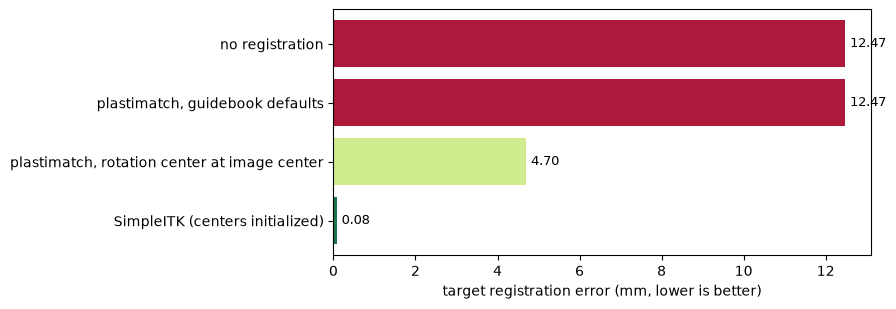

In [13]:
summary = [
    ("no registration", baseline),
    ("plastimatch, guidebook defaults", tre(transform)),
    ("plastimatch, rotation center at image center", tre(centered)),
    ("SimpleITK (centers initialized)", tre(sitk_transform)),
]

print(f"{'method':<46}{'TRE mm':>9}")
for name, value in summary:
    print(f"{name:<46}{value:>9.2f}")

# Color by the value itself, so lower error always reads as better.
values = np.array([s[1] for s in summary])
span = float(np.ptp(values)) or 1.0
shade = plt.cm.RdYlGn_r((values - values.min()) / span)

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.barh([s[0] for s in summary][::-1], values[::-1], color=shade[::-1], alpha=0.9)
ax.set_xlabel("target registration error (mm, lower is better)")
for y, v in enumerate(values[::-1]):
    ax.text(v + values.max() * 0.01, y, f"{v:.2f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

### What closed and what did not

The structural failure closed completely. Specifying the rotation center turns a silent
non-registration into a real one — no ITK errors, and the error drops from the baseline to a few
millimeters. The cause was identified by a controlled experiment rather than by guessing, and the
fix follows directly from it.

The **precision gap did not close.** SimpleITK still lands an order of magnitude closer. That is
left as an open question here rather than chased, because chasing it would mean going back to
permuting parameters without a hypothesis — the thing this chapter argues against.

If you want to pursue it, the most likely candidate is worth naming: SimpleITK's path uses a
**multi-resolution pyramid**, registering a heavily shrunk and smoothed version first and refining
at full resolution. The guidebook's plastimatch example is single-resolution. plastimatch supports
the same idea through `res` on successive `[STAGE]` blocks, so adding coarse-to-fine stages on top
of the rotation-center fix may narrow the gap. That is exercise 3.

## 9. What to take away

1. **Check overlap and center offset before registering.** Two numbers, and they tell you whether
   the problem is even well posed.
2. **Score in millimeters, not in parameters.** Transform conventions differ; residual distance does
   not.
3. **Never trust an exit code.** Read the transform. An identity result after a registration is a
   failure wearing a success costume.
4. **When something fails, find the one variable that controls it.** One controlled experiment beat
   thirteen parameter permutations here, and that ratio is typical.

## Exercises

1. Register the two real ACRIN timepoints with both engines. There is no ground truth, so judge by
   overlap of a body mask before and after. Does the 98 mm center offset behave as this chapter
   predicts?
2. Add `[STAGE] xform=translation` before the rigid stage on the real pair. Which component of the
   misalignment does it recover, and which does it leave?
3. Add coarse-to-fine stages (`res=4 4 2`, then `res=2 2 1`, then `res=1 1 1`) on top of the
   rotation-center fix and re-measure the TRE. Does the gap to SimpleITK narrow?
4. Take a registration that worked and shift the fixed image's origin by 2 meters. Predict what
   happens before running it.

## References

- [plastimatch registration command file reference](https://plastimatch.org/registration_command_file_reference.html)
- [plastimatch image registration guidebook](https://plastimatch.org/image_registration_guidebook.html)
- Sharp GC, Li R, Wolfgang J, et al. *Plastimatch: an open source software suite for radiotherapy
  image processing.* Proceedings of ICCR. 2010.
- Yaniv Z, Lowekamp BC, Johnson HJ, Beare R. *SimpleITK image-analysis notebooks: a collaborative
  environment for education and reproducible research.* J Digit Imaging. 2018;31(3):290–303.
- Machtay M, Duan F, Siegel BA, et al. *ACRIN 6668/RTOG 0235 trial.* J Clin Oncol. 2013;31(30):3823–3830.